Select conductor type:
1. Solid round
2. Stranded, 7 strands
3. Stranded, 19 strands
4. Stranded, 37 strands
5. ACSR 26/7


Enter conductor type (1-5):  3

Enter conductor radius r (m):  0.04
Enter vertical spacing between A and B phases (m):  0.5
Enter vertical spacing between B and C phases (m):  0.5
Enter horizontal spacing between the two circuits (m):  1



DOUBLE-CIRCUIT UNBUNDLED TRANSMISSION LINE
Conductor type              : Stranded, 19 strands
Conductor radius            : 0.040000 m
A-B phase spacing           : 0.500 m
B-C phase spacing           : 0.500 m
A-C phase spacing           : 1.000 m
Circuit spacing             : 1.000 m

Calculated Parameters
-------------------------------------------------------
Single-conductor GMR        : 3.032000e-02 m
Equivalent phase GMR        : 1.741264e-01 m
Equivalent GMD              : 8.727587e-01 m
Inductance per phase        : 3.223755e-07 H/m
Capacitance per phase       : 3.775860e-11 F/m

Results Table:


,Parameter,Value,Unit
0,Conductor radius,4.000000e-02,m
1,A-B spacing,5.000000e-01,m
2,B-C spacing,5.000000e-01,m
3,A-C spacing,1.000000e+00,m
4,Circuit spacing,1.000000e+00,m
5,Single-conductor GMR,3.032000e-02,m
6,Equivalent GMR,1.741264e-01,m
7,Equivalent GMD,8.727587e-01,m
8,Inductance per phase,3.223755e-07,H/m
9,Capacitance per phase,3.775860e-11,F/m


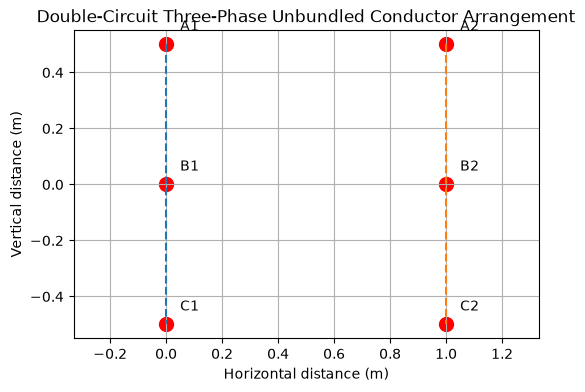

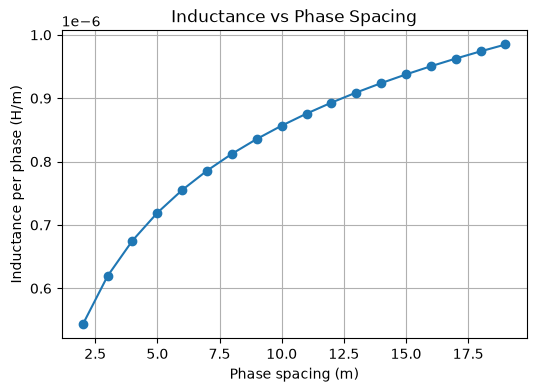

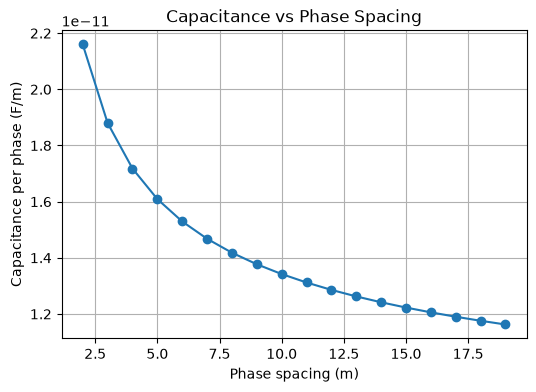

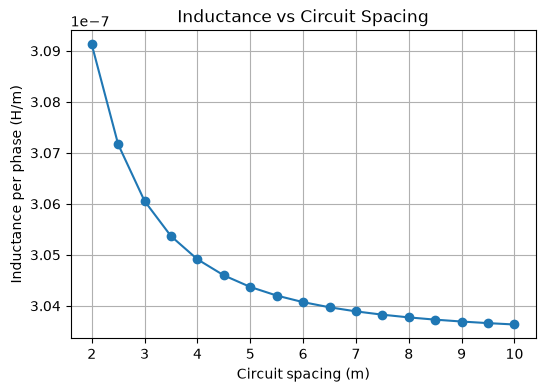

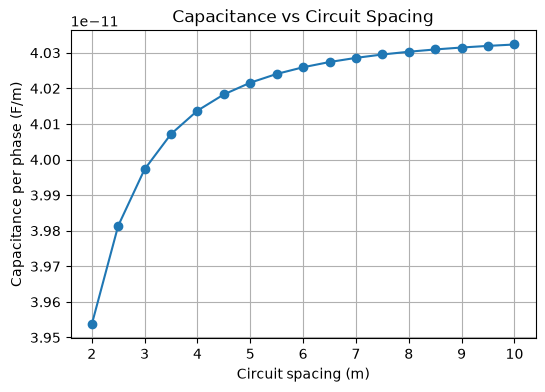


Conclusion:
The simulation shows that the physical arrangement of a double-circuit transmission line affects its equivalent GMR and GMD, and therefore its inductance and capacitance. Changes in phase spacing and circuit spacing produce corresponding changes in the transmission-line parameters.


In [4]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------------------------------------------------
# 1. SELECT CONDUCTOR TYPE
# ---------------------------------------------------------

conductor_types = {
    "1": ("Solid round", 0.7788),
    "2": ("Stranded, 7 strands", 0.726),
    "3": ("Stranded, 19 strands", 0.758),
    "4": ("Stranded, 37 strands", 0.768),
    "5": ("ACSR 26/7", 0.81)
}

print("Select conductor type:")
for key, value in conductor_types.items():
    print(f"{key}. {value[0]}")

choice = input("Enter conductor type (1-5): ")

conductor_name, gmr_factor = conductor_types[choice]


# ---------------------------------------------------------
# 2. ENTER CONDUCTOR RADIUS
# ---------------------------------------------------------

r = float(input("\nEnter conductor radius r (m): "))

# GMR of one conductor
GMR = gmr_factor * r


# ---------------------------------------------------------
# 3. ENTER TRANSMISSION LINE DIMENSIONS
# ---------------------------------------------------------

D_AB = float(input("Enter vertical spacing between A and B phases (m): "))
D_BC = float(input("Enter vertical spacing between B and C phases (m): "))

# Distance between A and C phases
D_AC = D_AB + D_BC

# Distance between the two circuits
D_CC = float(input("Enter horizontal spacing between the two circuits (m): "))


# ---------------------------------------------------------
# 4. DEFINE POSITIONS OF THE SIX CONDUCTORS
# ---------------------------------------------------------

# Circuit 1
A1 = (0, D_BC)
B1 = (0, 0)
C1 = (0, -D_AB)

# Circuit 2
A2 = (D_CC, D_BC)
B2 = (D_CC, 0)
C2 = (D_CC, -D_AB)


# ---------------------------------------------------------
# 5. DISTANCE FUNCTION
# ---------------------------------------------------------

def distance(p1, p2):
    return math.sqrt(
        (p1[0] - p2[0])**2 +
        (p1[1] - p2[1])**2
    )


# ---------------------------------------------------------
# 6. EQUIVALENT GMR FOR EACH PHASE
# ---------------------------------------------------------

# Each phase has one conductor in each circuit.
# The two same-phase conductors form an equivalent phase group.

GMR_eq = math.sqrt(GMR * D_CC)


# ---------------------------------------------------------
# 7. CALCULATE EQUIVALENT GMD
# ---------------------------------------------------------

# A-B distances
D_A1B1 = distance(A1, B1)
D_A1B2 = distance(A1, B2)
D_A2B1 = distance(A2, B1)
D_A2B2 = distance(A2, B2)

GMD_AB = (
    D_A1B1 *
    D_A1B2 *
    D_A2B1 *
    D_A2B2
) ** (1 / 4)


# B-C distances
D_B1C1 = distance(B1, C1)
D_B1C2 = distance(B1, C2)
D_B2C1 = distance(B2, C1)
D_B2C2 = distance(B2, C2)

GMD_BC = (
    D_B1C1 *
    D_B1C2 *
    D_B2C1 *
    D_B2C2
) ** (1 / 4)


# C-A distances
D_C1A1 = distance(C1, A1)
D_C1A2 = distance(C1, A2)
D_C2A1 = distance(C2, A1)
D_C2A2 = distance(C2, A2)

GMD_CA = (
    D_C1A1 *
    D_C1A2 *
    D_C2A1 *
    D_C2A2
) ** (1 / 4)


# Overall GMD
GMD = (
    GMD_AB *
    GMD_BC *
    GMD_CA
) ** (1 / 3)


# ---------------------------------------------------------
# 8. CALCULATE INDUCTANCE
# ---------------------------------------------------------

L = 2e-7 * math.log(GMD / GMR_eq)


# ---------------------------------------------------------
# 9. CALCULATE CAPACITANCE
# ---------------------------------------------------------

epsilon_0 = 8.854e-12

# Equivalent radius for the two conductors of each phase
r_eq = math.sqrt(r * D_CC)

C = (
    2 * math.pi * epsilon_0
) / math.log(GMD / r_eq)


# ---------------------------------------------------------
# 10. DISPLAY RESULTS
# ---------------------------------------------------------

print("\n" + "=" * 55)
print("DOUBLE-CIRCUIT UNBUNDLED TRANSMISSION LINE")
print("=" * 55)

print(f"Conductor type              : {conductor_name}")
print(f"Conductor radius            : {r:.6f} m")
print(f"A-B phase spacing           : {D_AB:.3f} m")
print(f"B-C phase spacing           : {D_BC:.3f} m")
print(f"A-C phase spacing           : {D_AC:.3f} m")
print(f"Circuit spacing             : {D_CC:.3f} m")

print("\nCalculated Parameters")
print("-" * 55)
print(f"Single-conductor GMR        : {GMR:.6e} m")
print(f"Equivalent phase GMR        : {GMR_eq:.6e} m")
print(f"Equivalent GMD              : {GMD:.6e} m")
print(f"Inductance per phase        : {L:.6e} H/m")
print(f"Capacitance per phase       : {C:.6e} F/m")


# ---------------------------------------------------------
# 11. CREATE RESULTS TABLE
# ---------------------------------------------------------

results = pd.DataFrame({
    "Parameter": [
        "Conductor radius",
        "A-B spacing",
        "B-C spacing",
        "A-C spacing",
        "Circuit spacing",
        "Single-conductor GMR",
        "Equivalent GMR",
        "Equivalent GMD",
        "Inductance per phase",
        "Capacitance per phase"
    ],

    "Value": [
        r,
        D_AB,
        D_BC,
        D_AC,
        D_CC,
        GMR,
        GMR_eq,
        GMD,
        L,
        C
    ],

    "Unit": [
        "m",
        "m",
        "m",
        "m",
        "m",
        "m",
        "m",
        "m",
        "H/m",
        "F/m"
    ]
})

print("\nResults Table:")
display(results)


# ---------------------------------------------------------
# 12. PLOT DOUBLE-CIRCUIT ARRANGEMENT
# ---------------------------------------------------------

plt.figure(figsize=(6, 4))

points = {
    "A1": A1,
    "B1": B1,
    "C1": C1,
    "A2": A2,
    "B2": B2,
    "C2": C2
}

for label, (x, y) in points.items():
    plt.scatter(x, y, s=100, color="red")
    plt.text(x + 0.05, y + 0.05, label)

# Circuit 1
plt.plot(
    [A1[0], B1[0], C1[0]],
    [A1[1], B1[1], C1[1]],
    linestyle="--"
)

# Circuit 2
plt.plot(
    [A2[0], B2[0], C2[0]],
    [A2[1], B2[1], C2[1]],
    linestyle="--"
)

plt.xlabel("Horizontal distance (m)")
plt.ylabel("Vertical distance (m)")
plt.title("Double-Circuit Three-Phase Unbundled Conductor Arrangement")
plt.grid(True)
plt.axis("equal")
plt.show()


# ---------------------------------------------------------
# 13. INDUCTANCE VS PHASE SPACING
# ---------------------------------------------------------

spacing_values = np.linspace(2, 19, 18)

L_values = []

for D in spacing_values:

    A1_test = (0, D)
    B1_test = (0, 0)
    C1_test = (0, -D)

    A2_test = (D_CC, D)
    B2_test = (D_CC, 0)
    C2_test = (D_CC, -D)

    GMD_AB_test = (
        distance(A1_test, B1_test) *
        distance(A1_test, B2_test) *
        distance(A2_test, B1_test) *
        distance(A2_test, B2_test)
    ) ** (1 / 4)

    GMD_BC_test = (
        distance(B1_test, C1_test) *
        distance(B1_test, C2_test) *
        distance(B2_test, C1_test) *
        distance(B2_test, C2_test)
    ) ** (1 / 4)

    GMD_CA_test = (
        distance(C1_test, A1_test) *
        distance(C1_test, A2_test) *
        distance(C2_test, A1_test) *
        distance(C2_test, A2_test)
    ) ** (1 / 4)

    GMD_test = (
        GMD_AB_test *
        GMD_BC_test *
        GMD_CA_test
    ) ** (1 / 3)

    L_test = 2e-7 * math.log(GMD_test / GMR_eq)

    L_values.append(L_test)


plt.figure(figsize=(6, 4))

plt.plot(
    spacing_values,
    L_values,
    marker="o"
)

plt.xlabel("Phase spacing (m)")
plt.ylabel("Inductance per phase (H/m)")
plt.title("Inductance vs Phase Spacing")
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 14. CAPACITANCE VS PHASE SPACING
# ---------------------------------------------------------

C_values = []

for D in spacing_values:

    A1_test = (0, D)
    B1_test = (0, 0)
    C1_test = (0, -D)

    A2_test = (D_CC, D)
    B2_test = (D_CC, 0)
    C2_test = (D_CC, -D)

    GMD_AB_test = (
        distance(A1_test, B1_test) *
        distance(A1_test, B2_test) *
        distance(A2_test, B1_test) *
        distance(A2_test, B2_test)
    ) ** (1 / 4)

    GMD_BC_test = (
        distance(B1_test, C1_test) *
        distance(B1_test, C2_test) *
        distance(B2_test, C1_test) *
        distance(B2_test, C2_test)
    ) ** (1 / 4)

    GMD_CA_test = (
        distance(C1_test, A1_test) *
        distance(C1_test, A2_test) *
        distance(C2_test, A1_test) *
        distance(C2_test, A2_test)
    ) ** (1 / 4)

    GMD_test = (
        GMD_AB_test *
        GMD_BC_test *
        GMD_CA_test
    ) ** (1 / 3)

    C_test = (
        2 * math.pi * epsilon_0
    ) / math.log(GMD_test / r_eq)

    C_values.append(C_test)


plt.figure(figsize=(6, 4))

plt.plot(
    spacing_values,
    C_values,
    marker="o"
)

plt.xlabel("Phase spacing (m)")
plt.ylabel("Capacitance per phase (F/m)")
plt.title("Capacitance vs Phase Spacing")
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 15. INDUCTANCE VS CIRCUIT SPACING
# ---------------------------------------------------------

circuit_spacing_values = np.linspace(2, 10, 17)

L_circuit_values = []

for S in circuit_spacing_values:

    GMR_test = math.sqrt(GMR * S)

    A1_test = (0, D_BC)
    B1_test = (0, 0)
    C1_test = (0, -D_AB)

    A2_test = (S, D_BC)
    B2_test = (S, 0)
    C2_test = (S, -D_AB)

    GMD_AB_test = (
        distance(A1_test, B1_test) *
        distance(A1_test, B2_test) *
        distance(A2_test, B1_test) *
        distance(A2_test, B2_test)
    ) ** (1 / 4)

    GMD_BC_test = (
        distance(B1_test, C1_test) *
        distance(B1_test, C2_test) *
        distance(B2_test, C1_test) *
        distance(B2_test, C2_test)
    ) ** (1 / 4)

    GMD_CA_test = (
        distance(C1_test, A1_test) *
        distance(C1_test, A2_test) *
        distance(C2_test, A1_test) *
        distance(C2_test, A2_test)
    ) ** (1 / 4)

    GMD_test = (
        GMD_AB_test *
        GMD_BC_test *
        GMD_CA_test
    ) ** (1 / 3)

    L_test = 2e-7 * math.log(GMD_test / GMR_test)

    L_circuit_values.append(L_test)


plt.figure(figsize=(6, 4))

plt.plot(
    circuit_spacing_values,
    L_circuit_values,
    marker="o"
)

plt.xlabel("Circuit spacing (m)")
plt.ylabel("Inductance per phase (H/m)")
plt.title("Inductance vs Circuit Spacing")
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 16. CAPACITANCE VS CIRCUIT SPACING
# ---------------------------------------------------------

C_circuit_values = []

for S in circuit_spacing_values:

    r_eq_test = math.sqrt(r * S)

    A1_test = (0, D_BC)
    B1_test = (0, 0)
    C1_test = (0, -D_AB)

    A2_test = (S, D_BC)
    B2_test = (S, 0)
    C2_test = (S, -D_AB)

    GMD_AB_test = (
        distance(A1_test, B1_test) *
        distance(A1_test, B2_test) *
        distance(A2_test, B1_test) *
        distance(A2_test, B2_test)
    ) ** (1 / 4)

    GMD_BC_test = (
        distance(B1_test, C1_test) *
        distance(B1_test, C2_test) *
        distance(B2_test, C1_test) *
        distance(B2_test, C2_test)
    ) ** (1 / 4)

    GMD_CA_test = (
        distance(C1_test, A1_test) *
        distance(C1_test, A2_test) *
        distance(C2_test, A1_test) *
        distance(C2_test, A2_test)
    ) ** (1 / 4)

    GMD_test = (
        GMD_AB_test *
        GMD_BC_test *
        GMD_CA_test
    ) ** (1 / 3)

    C_test = (
        2 * math.pi * epsilon_0
    ) / math.log(GMD_test / r_eq_test)

    C_circuit_values.append(C_test)


plt.figure(figsize=(6, 4))

plt.plot(
    circuit_spacing_values,
    C_circuit_values,
    marker="o"
)

plt.xlabel("Circuit spacing (m)")
plt.ylabel("Capacitance per phase (F/m)")
plt.title("Capacitance vs Circuit Spacing")
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 17. CONCLUSION
# ---------------------------------------------------------

print("\nConclusion:")

print(
    "The simulation shows that the physical arrangement of a double-circuit "
    "transmission line affects its equivalent GMR and GMD, and therefore its "
    "inductance and capacitance. Changes in phase spacing and circuit spacing "
    "produce corresponding changes in the transmission-line parameters."
)